# Normals in 3D Graphics & 3D AI  
_A hands-on tutorial covering:_  
1. What is a normal? (Definition & math)  
2. Normals on polygonal meshes  
3. Color-coded normal maps: how to read them  
4. Normals in Neural Radiance Fields (NeRF)  
5. Normals in Gaussian Splatting  
6. Advanced topics: smoothing, blending, differentiable normals  

## 1. What Is a Normal?  

A **normal vector** at a point on a surface is a unit-length vector perpendicular to the tangent plane.  
- **Plane**: constant normal.  
- **Sphere**: normals point radially outward.

**Math recap**:  
- If surface defined as $F(x,y,z)=0$, then normal is $\mathbf n = \frac{\nabla F}{\|\nabla F\|}.$  

- For a parametric surface $\mathbf r(u,v),$ then normal is $ \mathbf n = \frac{\partial_u \mathbf r \times \partial_v \mathbf r}{\|\partial_u \mathbf r \times \partial_v \mathbf r\|}.$



So a **normal vector** to a surface at a point is a vector perpendicular to the tangent plane at that point.

For a triangle mesh, the face normal $N_f$  is given by the cross product of two edge vectors:  
$ N_f = normalize(cross(v1 - v0, v2 - v0))$ 


The **vertex normal** is usually the average of the normals of the faces that share the vertex.

In neural rendering (e.g., **NeRF**), normals are usually estimated from the gradient of the signed distance function or density field:  
$ n = normalize(grad(SDF(x)))$ 


In **Gaussian Splatting**, normals are used to orient each Gaussian ellipse in space for better light
scattering and filtering.


## 2. Normals on Polygonal Meshes  

### 2.1 Face normals  
For triangle with vertices **a**, **b**, **c**:  


In [3]:
import numpy as np

def face_normal(a, b, c):
    # compute two edge vectors
    e1 = b - a
    e2 = c - a
    # cross product gives perpendicular
    n = np.cross(e1, e2)
    return n / np.linalg.norm(n)

# Example
a = np.array([0,0,0])
b = np.array([1,0,0])
c = np.array([0,1,0])
print("Face normal:", face_normal(a,b,c))

Face normal: [0. 0. 1.]


### 2.2 Vertex normals (smoothing)
Average the normals of adjacent faces:

In [19]:
def vertex_normals(vertices, faces):
    N = len(vertices)
    vnorm = np.zeros((N,3), dtype=float)
    for (i,j,k) in faces:
        fn = face_normal(vertices[i], vertices[j], vertices[k])
        for idx in (i,j,k):
            vnorm[idx] += fn
    # Normalize
    vnorm /= np.linalg.norm(vnorm, axis=1, keepdims=True)
    return vnorm

## 3. Normals in NeRF

**Neural Radiance Fields (NeRF)** represent a scene as a continuous volumetric field:

$F(\mathbf{x}, \mathbf{d}) \rightarrow (\sigma, \mathbf{c})$

Where:
- $\mathbf{x} \in \mathbb{R}^3$: 3D spatial location
- $\mathbf{d} \in \mathbb{S}^2$: viewing direction
- $\sigma$: volumetric density
- $\mathbf{c}$: emitted color or radiance


### Surface Normals from NeRF

To extract **surface normals** from a NeRF, one leverages the fact that surfaces lie in regions of high density. The gradient of the accumulated density with respect to position approximates the surface normal:

$
\mathbf{n}(\mathbf{x}) = \frac{\nabla_{\mathbf{x}} \tau(\mathbf{x})}{\| \nabla_{\mathbf{x}} \tau(\mathbf{x}) \|}
$

Where:
- $\tau(\mathbf{x})$ is the accumulated transmittance or opacity along a ray passing through $\mathbf{x}$
- In practice, $\tau(\mathbf{x}) = \int_0^\infty \sigma(\mathbf{x}(t)) dt$

### Practical Computation (via Autograd)

In differentiable frameworks like PyTorch or JAX, normals can be estimated by computing the gradient of the density field:


In [20]:
import torch

# x: spatial point where normal is to be estimated
# nerf_model: function returning (sigma, color) given (x, direction)

def estimate_normal(nerf_model, x):
    x = x.clone().detach().requires_grad_(True)
    sigma, _ = nerf_model(x, d=None)  # only density matters for normal
    sigma_sum = sigma.sum()          # accumulate density
    grad = torch.autograd.grad(sigma_sum, x)[0]
    return grad / grad.norm(dim=-1, keepdim=True)

## 4. Normals in Gaussian Splatting
Gaussian Splatting places 3D Gaussians in space - each has a covariance ellipsoid.

The “normal” of a Gaussian can be taken as the principal axis of its covariance.

Clip a slice through the ellipsoid at half-max → fit tangent plane → normal = major eigenvector of covariance.

## 5 Color-Coded Normal Maps

To interpret normal color coding, you need to know what camera coordinate convention the authors are using. 

A normal map encodes surface normals in RGB:

- R → X component (mapped from [−1,1] to [0,1])

- G → Y component

- B → Z component

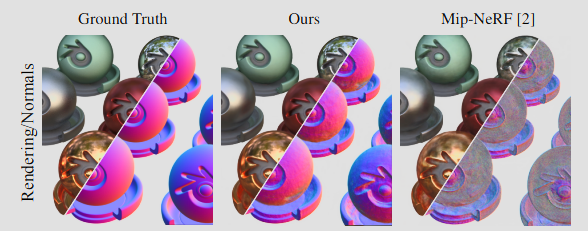

Interpreting the tri-sphere montage

The left-half “ground truth” uses world-space normals: greens/blues indicate upward Z, reds indicate X-axis variation.

The right-half “MIP-NeRF” has noisy normals → color speckle.

In [21]:
from PIL import Image
import numpy as np

# load a normal map (example file)
#nm = np.array(Image.open('normal_map.png')) / 255.0
# decode back to vector ∈ [−1,1]
nm = np.zeros((101, 101, 3), dtype=float)
nm[..., 2] = 1
#nm[..., 0] = 1
#nm[..., 1] = 1
normals = nm * 2 - 1
# For a pixel:
px = normals[100,100]
print("Decoded normal at (100,100):", px)

Decoded normal at (100,100): [-1. -1.  1.]


### Visualization: Render a Mesh with Normals

In [22]:
# pip install trimesh pyrender
import trimesh, pyrender
import numpy as np

# create or load a mesh
mesh = trimesh.creation.icosphere(subdivisions=3, radius=1.0)
# compute per-vertex normals
vn = mesh.vertex_normals
# color by normal (to visualize)
colors = ((vn + 1) * 0.5 * 255).astype(np.uint8)
mesh.visual.vertex_colors = colors

# render
scene = pyrender.Scene()
scene.add(pyrender.Mesh.from_trimesh(mesh, smooth=False))
viewer = pyrender.Viewer(scene, use_raymond_lighting=True)


### How to Interpret the Colors

For this example we are using right-handed coordinate system, with Y-up convention.
Rendering uses OpenGL conventions:

+X → right

+Y → up

+Z → toward the camera (viewer)

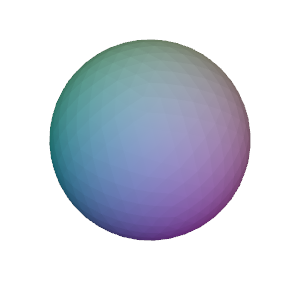

Each RGB color encodes a 3D normal direction:

| Color         | Direction                                |
| ------------- | ---------------------------------------- |
| **Red (R)**   | X-axis → +X is red, −X is cyan           |
| **Green (G)** | Y-axis → +Y is green, −Y is magenta      |
| **Blue (B)**  | Z-axis → +Z is blue, −Z is yellow/orange |

So if:

- You see green at the top, that part of the sphere has a normal pointing up (+Y).

- You see purple/magenta at the bottom, it's pointing down (−Y).

- Teal/blue in the center indicates normals pointing toward the viewer (+Z).

- Red or orange at the sides → normals pointing along ±X.

### Vector Examples

To understand visually, consider these mappings:

| Normal Vector (x, y, z) | RGB Color       | Color Swatch                                | Meaning                    |
|--------------------------|------------------|----------------------------------------------|-----------------------------|
| (1, 0, 0)                | (255, 127, 127)  | <span style="display:inline-block;width:50px;height:20px;background-color:rgb(255,127,127);"></span> | Right (pure +X)             |
| (-1, 0, 0)               | (0, 127, 127)    | <span style="display:inline-block;width:50px;height:20px;background-color:rgb(0,127,127);"></span>   | Left (pure -X)              |
| (0, 1, 0)                | (127, 255, 127)  | <span style="display:inline-block;width:50px;height:20px;background-color:rgb(127,255,127);"></span> | Up (+Y)                     |
| (0, -1, 0)               | (127, 0, 127)    | <span style="display:inline-block;width:50px;height:20px;background-color:rgb(127,0,127);"></span>   | Down (-Y)                   |
| (0, 0, 1)                | (127, 127, 255)  | <span style="display:inline-block;width:50px;height:20px;background-color:rgb(127,127,255);"></span> | Toward screen (+Z)          |
| (0, 0, -1)               | (127, 127, 0)    | <span style="display:inline-block;width:50px;height:20px;background-color:rgb(127,127,0);"></span>   | Into screen (−Z)            |
